<a href="https://colab.research.google.com/github/sarj29/PeerPro---DeepLearning-with-Neural-Networks/blob/main/iris_preprocess_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [ ]:
!ls

Iris.csv  sample_data


In [5]:
import pandas as pd

df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
X = df.drop(["Id", "Species"], axis=1)
y = df["Species"]

In [7]:
from sklearn.preprocessing import LabelEncoder

#Iris-setosa -> 0,Iris-versicolor -> 1,Iris-virginica -> 2

le = LabelEncoder()
y = le.fit_transform(y)

In [8]:
print(X.isnull().sum()) #no missing values

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
dtype: int64


In [ ]:
print(X.duplicated().sum())
#X = X.drop_duplicates() - error : input variables with inconsistent numbers of samples

In [ ]:
import matplotlib.pyplot as plt

X.boxplot(figsize=(8,5))
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.90068117  1.03205722 -1.3412724  -1.31297673]
 [-1.14301691 -0.1249576  -1.3412724  -1.31297673]
 [-1.38535265  0.33784833 -1.39813811 -1.31297673]
 [-1.50652052  0.10644536 -1.2844067  -1.31297673]
 [-1.02184904  1.26346019 -1.3412724  -1.31297673]]


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


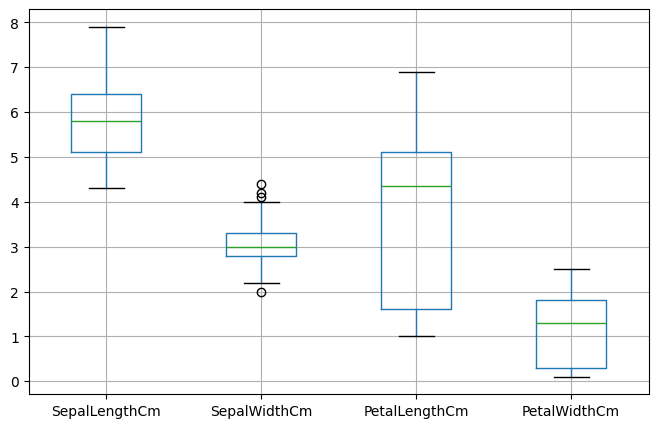

In [ ]:
import matplotlib.pyplot as plt

X.boxplot(figsize=(8,5))
plt.show()

The boxplot was used to identify outliers and understand feature distributions. SepalWidthCm contains a few outlier values, visible as points outside the whiskers. The remaining features do not show significant outliers. The spread of PetalLengthCm and PetalWidthCm is relatively large, indicating strong variation among Iris species.

In [1]:
import torch
import torch.nn as  #layers of neural networks
import torch.optim as optim #optimizers (how the model learns)

In [12]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [14]:
class IrisNN(nn.Module):

  def __init__(self):
    super().__init__()

#Linear means Fully Connected Layer.

    self.fc1 = nn.Linear(4,16) #16 hidden neurons
    self.fc2 = nn.Linear(16,8)
    self.fc3 = nn.Linear(8,3) #Iris has 3 flower species

    self.relu = nn.ReLU()

  def forward(self,x):
#defines how the data travels through the network.
    x = self.relu(self.fc1(x))
    x = self.relu(self.fc2(x))
    x = self.fc3(x)
#No ReLU here because,CrossEntropyLoss, expects the raw scores (logits).
    return x

In [15]:
model = IrisNN()
print(model)

IrisNN(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=3, bias=True)
  (relu): ReLU()
)


In [16]:
#Loss Function & Optimizer

#measures how wrong the predictions are.
criterion = nn.CrossEntropyLoss()

#Adaptive Moment Estimation : updates network weights by combining the strengths of two other methods: Momentum (to accelerate training) and RMSprop (to adaptively scale learning rates)
optimizer = optim.Adam(model.parameters(), lr = 0.01)

#model.parameters() tells Adam which weights to update.
#lr=0.01 is the learning rate, controlling how large each update step is.

In [17]:
epochs = 100
#network sees the entire training dataset 100 times, 1 at a time.
for epoch in range(epochs):

    #Forward pass – make predictions:
    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    #Clear old gradients:
    optimizer.zero_grad()

    loss.backward()

    #Update weights:
    optimizer.step()

    if (epoch+1)%10 == 0:
        print(f"Epoch {epoch+1}, Loss = {loss.item():.4f}")

Epoch 10, Loss = 0.8654
Epoch 20, Loss = 0.5688
Epoch 30, Loss = 0.3975
Epoch 40, Loss = 0.2688
Epoch 50, Loss = 0.1743
Epoch 60, Loss = 0.1025
Epoch 70, Loss = 0.0734
Epoch 80, Loss = 0.0592
Epoch 90, Loss = 0.0526
Epoch 100, Loss = 0.0491


In [18]:
#This tells PyTorch you're only testing, not training. It saves memory by not computing gradients.

with torch.no_grad():

    outputs = model(X_test)

#Selects the class with the highest score for each flower.
    _, predicted = torch.max(outputs,1)

# Accuracy =
# (Number of Correct Predictions)
#  --------------------------------
# (Total Number of Test Samples)
    accuracy = (predicted == y_test).sum().item()/len(y_test)

print("Accuracy:", accuracy*100,"%")

Accuracy: 100.0 %


In [19]:
print("Predicted:")
print(predicted)

print("\nActual:")
print(y_test)

Predicted:
tensor([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2, 0, 2,
        2, 2, 2, 2, 0, 0])

Actual:
tensor([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2, 0, 2,
        2, 2, 2, 2, 0, 0])


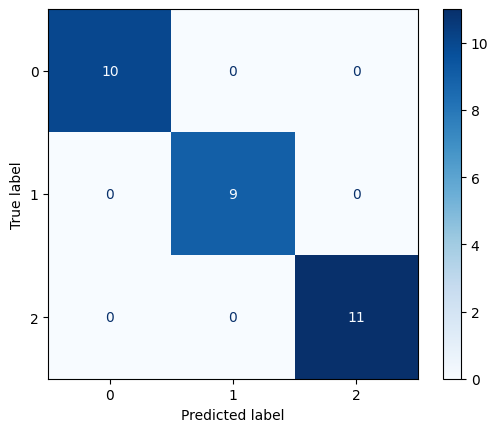

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test.numpy(),
    predicted.numpy()
)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")

plt.show()